# News Bias Detector Project

Step 1: Data Collection

Step 2: Data Preprocessing

Step 3: Model Implementation

Step 4: Model Fine Tuning

Step 5: Model Evaluation

# **Setup**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/MyDrive/CIS5190project/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from pandas.plotting import parallel_coordinates
from sklearn.metrics import classification_report
import pandas as pd
import requests
from bs4 import BeautifulSoup
import csv
import time
import random
from concurrent.futures import ThreadPoolExecutor, as_completed
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from collections import Counter

#  **Data Collection & Preprocessing**

In [ ]:
def scrape_headline(url):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/100.0.4896.75 Safari/537.36"
        ),
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8"
    }
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")

    headline_element = soup.find("h1")
    if headline_element:
        headline = headline_element.get_text(strip=True)
        print("Headline found in <h1>:", headline)
        return headline
    meta_headline = soup.find("meta", property="og:title")
    if meta_headline and meta_headline.get("content"):
        headline = meta_headline["content"]
        print("Headline found in meta tag:", headline)
        return headline

    print("No headline found for this URL.")
    return None

def main():
    output_file = "scraped_headlines.csv"
    with open(output_file, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["URL", "Headline"])

    successful_urls = []
    successful_headlines = []


    for index, row in df_train_url.iterrows():
        url = row['url']
        success = False
        attempts = 0
        max_attempts = 3

        while not success and attempts < max_attempts:
            try:
                print(f"\nScraping URL: {url}")
                headline = scrape_headline(url)
                if headline:
                    successful_urls.append(url)
                    successful_headlines.append(headline)

                    with open(output_file, mode="a", newline="", encoding="utf-8") as f:
                        writer = csv.writer(f)
                        writer.writerow([url, headline])
                    print(f"append {url} into csv")
                else:
                    print(f"can't find the title in {url}")
                success = True
            except Exception as e:
                attempts += 1
                print(f"{url} fail，the {attempts} time attempt error:{e}")

                wait_time = random.uniform(2, 5)
                print(f"wait {wait_time:.2f} second")
                time.sleep(wait_time)


        delay = random.uniform(1, 3)
        time.sleep(delay)


    print("\nCollected Headlines:")
    for idx, (url, headline) in enumerate(zip(successful_urls, successful_headlines), start=1):
        print(f"{idx}. {url} - {headline}")

if __name__ == "__main__":
    main()

In [ ]:
# downloading required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def preprocess_text(text):
    """
    Cleaning and preprocessing headline string,,
      1) Converting text to lowercase,
      2) Removing punctuation and non alphabetic characters,
      3) Tokenizing by splitting on whitespace,
      4)) Removing common English stopwords,
      5) Lemmatizing tokens to base form
      6) Returning processed tokens as joined string
    """
    if not isinstance(text, str):
        return ""

    #converting text to lowercase
    text = text.lower()

    # removing punctuation and non alphabetic characters
    text = re.sub(r'[^a-z\s]', '', text)

    # tokenizing by splitting on whitespace
    tokens = text.split()

    #removing stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatizing tokens
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return " ".join(tokens)

# Reading collected headlines from CSV file
input_file = "scraped_headlines.csv"
df = pd.read_csv(input_file)

# removing duplicate headlines
df.drop_duplicates(subset=['Headline'], inplace=True)

# Creating new column for cleaned headlines
df['Cleaned_Headline'] = df['Headline'].apply(preprocess_text)

# Saving preprocessed data to new CSV file
output_file = "preprocessed_headlines.csv"
df.to_csv(output_file, index=False)

# Data Validation (displays mean length of headlines)
df['Word_Count'] = df['Cleaned_Headline'].apply(lambda x: len(x.split()))
average_length = df['Word_Count'].mean()
print("Average length of headlines:", average_length)

# Word Frequency (shows which words are most common amonbst headlines)
all_words = " ".join(df['Cleaned_Headline']).split()
word_freq = Counter(all_words)
most_common_words = word_freq.most_common(10)
print("Most common words:", most_common_words)

# Manual Inspection (show an exmaple line of the cleaned dataset)
print(df[['Headline', 'Cleaned_Headline']].head(sample_size).to_string())

print("Preprocessing complete. Preprocessed data saved to:", output_file)


# **Baseline Model:Logistic Regression & TF-IDF Model**

In [ ]:
#Training and testing with data
import pandas as pd
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from collections import Counter

Accuracy on Test Data: 81.11%

Classification Report:
               precision    recall  f1-score   support

     foxnews       0.78      0.89      0.83       400
     nbcnews       0.85      0.72      0.78       357

    accuracy                           0.81       757
   macro avg       0.82      0.81      0.81       757
weighted avg       0.82      0.81      0.81       757



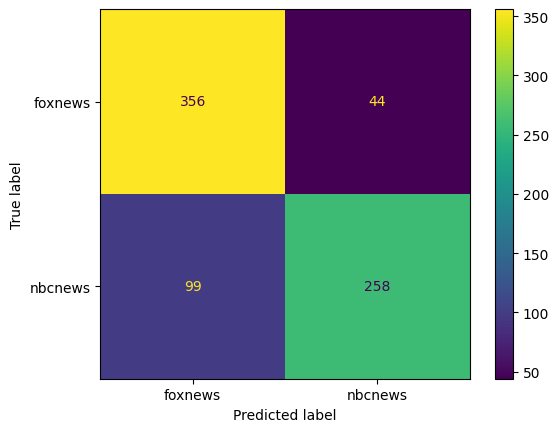

In [ ]:
# Reading preprocessed data
df = pd.read_csv("preprocessed_headlines.csv")

#extracting domain, news source, from URL
def extract_domain(url):
    try:
        parsed_url = urlparse(url)
        return parsed_url.netloc
    except Exception:
        return "unknown"

def unify_domain(domain):
  if domain is None:
    return None
  if 'foxnews' in domain:
    return 'foxnews'
  elif 'nbcnews' in domain:
    return 'nbcnews'
  else:
    return None

# Creating new column 'Source' by extracting domain from URL
df['Source'] = df['URL'].apply(unify_domain)


# using Cleaned_Headline as feature and domain as label
X = df['Cleaned_Headline']
y = df['Source']

#splitting dataset into training and testing sets, 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# vectorizing text data using TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


# training logistic regression classifier
baseline = LogisticRegression(max_iter=200)
baseline.fit(X_train_tfidf, y_train)

# predicting on test set
y_pred = baseline.predict(X_test_tfidf)

#evaluating classifier
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy on Test Data: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:\n", report)
ConfusionMatrixDisplay.from_estimator(baseline, X_test_tfidf, y_test, values_format = '.0f')

# **Classification Model Selection**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
# Create a LabelEncoder to convert string labels to numerical labels
label_encoder = LabelEncoder()

# Fit the LabelEncoder on the training target variable and transform both training and testing target variables
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Define the list of models to evaluate
models = [
    ("Naive Bayes", MultinomialNB()),
    ("Logistic Regression", LogisticRegression(max_iter=200)),
    ("SVM (LinearSVC)", LinearSVC()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42)),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42)),
    ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("Bagging", BaggingClassifier(random_state=42)),
    ("Radius Neighbors", RadiusNeighborsClassifier(radius=10)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
    ("KNN", KNeighborsClassifier()),
    ("MLP", MLPClassifier(max_iter=300, random_state=42)),
]

# Dictionary to store the accuracy of each model
model_accuracies = {}

# Train and evaluate each model, then record the accuracy
for name, model in models:
    # Fit the model using the encoded target variable for training
    model.fit(X_train_tfidf, y_train_encoded)

    # Predict using the encoded target variable for testing
    y_pred_encoded = model.predict(X_test_tfidf)

    # Transform predictions back to original labels for evaluation
    y_pred = label_encoder.inverse_transform(y_pred_encoded)

    accuracy = accuracy_score(y_test, y_pred)
    model_accuracies[name] = accuracy * 100  # Convert to percentage
    print(f"Model: {name}, Accuracy: {accuracy * 100:.2f}%")



Model: Naive Bayes, Accuracy: 79.92%
Model: Logistic Regression, Accuracy: 81.11%
Model: SVM (LinearSVC), Accuracy: 81.90%
Model: Decision Tree, Accuracy: 70.81%
Model: Random Forest, Accuracy: 77.54%
Model: Gradient Boosting, Accuracy: 74.50%
Model: AdaBoost, Accuracy: 62.62%
Model: Bagging, Accuracy: 75.69%
Model: Radius Neighbors, Accuracy: 52.84%


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:42:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: XGBoost, Accuracy: 77.28%
Model: KNN, Accuracy: 77.94%
Model: MLP, Accuracy: 79.92%


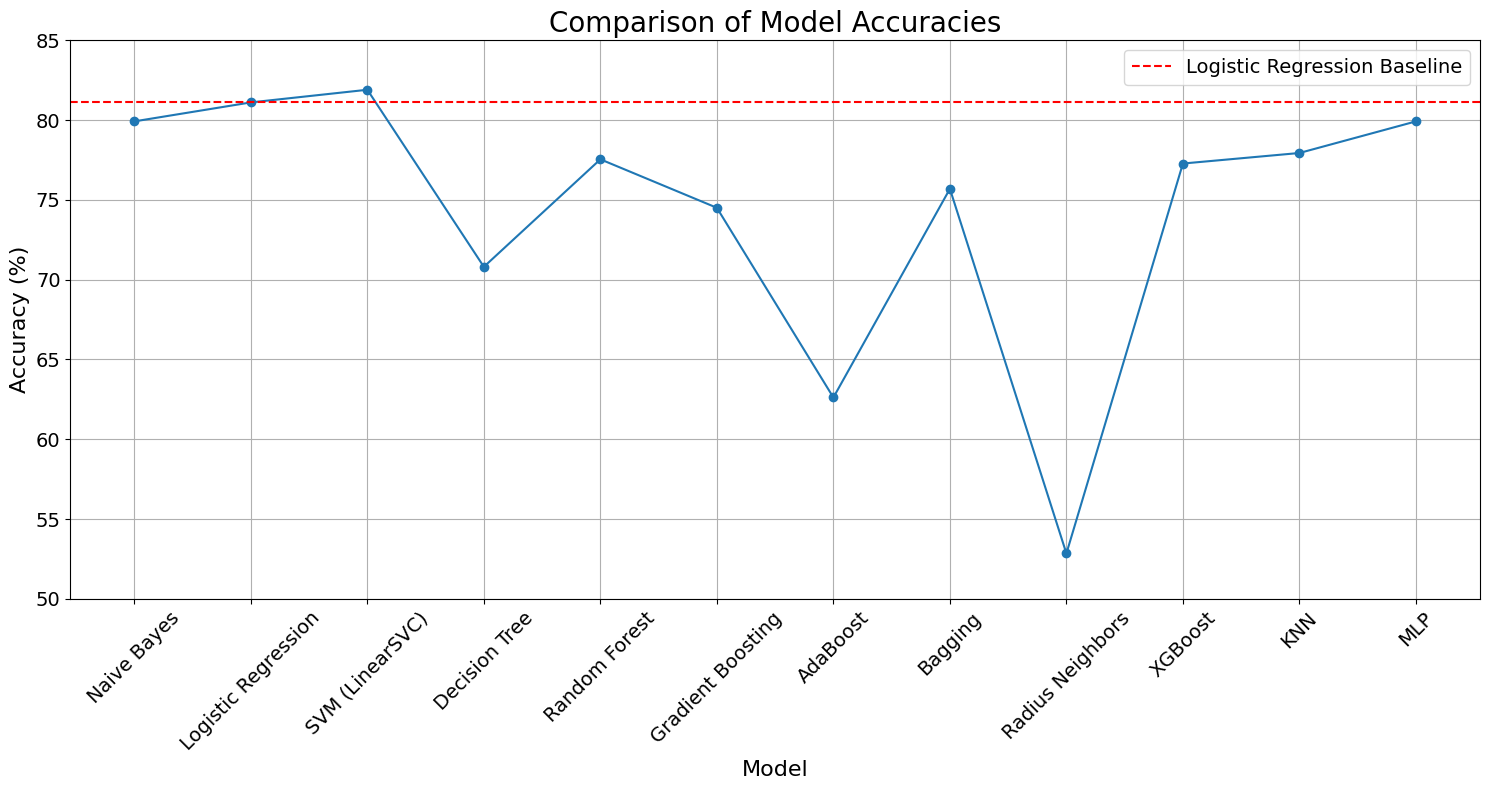

In [ ]:
# Plot a line chart to compare model accuracies
logistic_baseline = model_accuracies["Logistic Regression"]
plt.figure(figsize=(15, 8))
plt.plot(
    list(model_accuracies.keys()),
    list(model_accuracies.values()),
    marker='o',
    linestyle = '-',
)
plt.axhline(
    y=logistic_baseline,
    color = 'red',
    linestyle='--',  # dashed line
    label="Logistic Regression Baseline"
)

plt.title("Comparison of Model Accuracies",fontsize=20)
plt.xlabel("Model",fontsize=16)
plt.ylabel("Accuracy (%)",fontsize=16)
plt.ylim([50, 85])
plt.xticks(rotation=45,fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize = 14)  # so the baseline label shows up
plt.tight_layout()
plt.show()

From the Graph we can know that the Naibe Bayes, Logistic Regression and SVM has the best performance. Followed by KNN and MLP. So the next step we will use these 5 model to do the hyperparameter tuning.

# **Hyperparameter Tuning for Logistic Regression & SVC Linear**

## **Logistic Regression Hyperparameter Tuning**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:

param_grid = {
    'vectorizer__max_features': [None, 500, 1000, 2000],
    'vectorizer__ngram_range': [(1,1),(1,2)],
    'vectorizer__min_df': [1,2,5],
    'vectorizer__max_df': [0.9,1.0],
    'vectorizer__sublinear_tf': [True, False],
    'vectorizer__use_idf': [True, False],
    'vectorizer__norm': ['l2','l1', None],
    'classifier__C': [0.1,1,10,100],
    'classifier__solver': ['lbfgs','liblinear','saga'],
    'classifier__max_iter': [200,300]
}

#Training
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Set the pipeline
pipe = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(max_iter=200))
])

#Split the Train/Validation/Test
cv = StratifiedShuffleSplit(
    n_splits=3,
    train_size=0.75,
    test_size=0.25,
    random_state=42
)

# Grid search
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
    error_score=np.nan
)

grid_search.fit(X_trainval, y_trainval)


print("Best Parameters found:", grid_search.best_params_)
print("Best CV Score: {:.2f}%".format(grid_search.best_score_ * 100))


best_baseline = grid_search.best_estimator_
y_pred = best_baseline.predict(X_test)

print("Accuracy on Test Data: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Alias for final submission
final_model = best_baseline


Fitting 3 folds for each of 13824 candidates, totalling 41472 fits
Best Parameters found: {'classifier__C': 0.1, 'classifier__max_iter': 200, 'classifier__solver': 'lbfgs', 'vectorizer__max_df': 0.9, 'vectorizer__max_features': None, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2), 'vectorizer__norm': None, 'vectorizer__sublinear_tf': True, 'vectorizer__use_idf': True}
Best CV Score: 80.80%
Accuracy on Test Data: 82.83%

Classification Report:
               precision    recall  f1-score   support

     foxnews       0.83      0.84      0.84       400
     nbcnews       0.82      0.81      0.82       357

    accuracy                           0.83       757
   macro avg       0.83      0.83      0.83       757
weighted avg       0.83      0.83      0.83       757



In [ ]:
baseline_report = classification_report(y_test, baseline.predict(X_test_tfidf), output_dict=True)
baseline_df = pd.DataFrame(baseline_report).transpose().round(2)

grid_report = classification_report(y_test, best_baseline.predict(X_test), output_dict=True)
grid_df = pd.DataFrame(grid_report).transpose().round(2)

print("Baseline Model Metrics:\n", baseline_df)
print("\nGrid Search Best Model Metrics:\n", grid_df)

Baseline Model Metrics:
               precision  recall  f1-score  support
foxnews            0.78    0.89      0.83   400.00
nbcnews            0.85    0.72      0.78   357.00
accuracy           0.81    0.81      0.81     0.81
macro avg          0.82    0.81      0.81   757.00
weighted avg       0.82    0.81      0.81   757.00

Grid Search Best Model Metrics:
               precision  recall  f1-score  support
foxnews            0.83    0.84      0.84   400.00
nbcnews            0.82    0.81      0.82   357.00
accuracy           0.83    0.83      0.83     0.83
macro avg          0.83    0.83      0.83   757.00
weighted avg       0.83    0.83      0.83   757.00


## **SVM Hyperparameter Tuning**


In [ ]:
SVM = LinearSVC()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV
from scipy.stats import uniform, randint


pipe = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LinearSVC()),
])

param_distributions = {
    'vectorizer__max_features': [None, 500, 1000, 2000],
    'vectorizer__ngram_range': [(1,1), (1,2)],
    'vectorizer__max_df': [0.75, 1.0],
    'vectorizer__min_df': [1, 2, 5],
    'vectorizer__max_features': [None, 1000, 5000],
    'vectorizer__sublinear_tf': [False, True],
    'vectorizer__use_idf': [True, False],
    'vectorizer__norm': ['l2', 'l1', None],


    'classifier__penalty': ['l2', 'l1'],
    'classifier__loss': ['squared_hinge', 'hinge'],
    'classifier__dual': [True, False],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__tol': [1e-5, 1e-4, 1e-3],
    'classifier__max_iter': [1000, 2000],
    'classifier__class_weight': [None, 'balanced'],
}


cv_split = StratifiedShuffleSplit(
    n_splits=3,
    train_size=0.75,
    test_size=0.25,
    random_state=42
)


random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=1000,
    cv=cv_split,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)


print("Best Parameters (random search):", random_search.best_params_)
print("Best CV Accuracy: {:.2f}%".format(random_search.best_score_ * 100))


best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 1000 candidates, totalling 3000 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1413 fits failed out of a total of 3000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
261 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y,

Best Parameters (random search): {'vectorizer__use_idf': True, 'vectorizer__sublinear_tf': False, 'vectorizer__norm': 'l1', 'vectorizer__ngram_range': (1, 2), 'vectorizer__min_df': 1, 'vectorizer__max_features': None, 'vectorizer__max_df': 0.75, 'classifier__tol': 1e-05, 'classifier__penalty': 'l2', 'classifier__max_iter': 2000, 'classifier__loss': 'hinge', 'classifier__dual': True, 'classifier__class_weight': 'balanced', 'classifier__C': 10.0}
Best CV Accuracy: 80.71%
Test Accuracy: 81.90%

Classification Report:
               precision    recall  f1-score   support

     foxnews       0.82      0.85      0.83       400
     nbcnews       0.82      0.78      0.80       357

    accuracy                           0.82       757
   macro avg       0.82      0.82      0.82       757
weighted avg       0.82      0.82      0.82       757



In [ ]:
vec_params = pipe_2.named_steps['vectorizer'].get_params()
print("\nTfidfVectorizer default params:\n", vec_params)

svc_params = pipe_2.named_steps['classifier'].get_params()
print("\nLinearSVC default params:\n", svc_params)


TfidfVectorizer default params:
 {'analyzer': 'word', 'binary': False, 'decode_error': 'strict', 'dtype': <class 'numpy.float64'>, 'encoding': 'utf-8', 'input': 'content', 'lowercase': True, 'max_df': 1.0, 'max_features': None, 'min_df': 1, 'ngram_range': (1, 1), 'norm': 'l2', 'preprocessor': None, 'smooth_idf': True, 'stop_words': None, 'strip_accents': None, 'sublinear_tf': False, 'token_pattern': '(?u)\\b\\w\\w+\\b', 'tokenizer': None, 'use_idf': True, 'vocabulary': None}

LinearSVC default params:
 {'C': 1.0, 'class_weight': None, 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'squared_hinge', 'max_iter': 1000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': None, 'tol': 0.0001, 'verbose': 0}


In [ ]:
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

svm_report = classification_report(
    y_test,
    svm.predict(X_test_tfidf),
    output_dict=True
)
svm_df = pd.DataFrame(svm_report).transpose().round(2)

best_rs = random_search.best_estimator_

rs_report = classification_report(
    y_test,
    best_rs.predict(X_test),
    output_dict=True
)
rs_df = pd.DataFrame(rs_report).transpose().round(2)

print("Baseline SVM Metrics:\n", svm_df)
print("\nRandom Search Best Model Metrics:\n", rs_df)

Baseline SVM Metrics:
               precision  recall  f1-score  support
foxnews            0.82    0.85      0.83   400.00
nbcnews            0.82    0.79      0.80   357.00
accuracy           0.82    0.82      0.82     0.82
macro avg          0.82    0.82      0.82   757.00
weighted avg       0.82    0.82      0.82   757.00

Random Search Best Model Metrics:
               precision  recall  f1-score  support
foxnews            0.82    0.85      0.83   400.00
nbcnews            0.82    0.78      0.80   357.00
accuracy           0.82    0.82      0.82     0.82
macro avg          0.82    0.82      0.82   757.00
weighted avg       0.82    0.82      0.82   757.00


# **CNN Model** (Using Tensorflow)

In [ ]:
!pip install tensorflow

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, LSTM, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [ ]:
print(X_train.head(10))
print(y_train.head(10))
print(X_test.head(10))
print(y_test.head(10))

3437    fbi swat team hunt exnational guardsman wanted...
682     taylor swift sits separate brittany mahomes ch...
3640    north korea blow interkorean road rail line ne...
1606    progressive dem slam reprehensible repulsive r...
454     nevada gov back womens volleyball player refus...
2060    sen mike lee promotes debunked conspiracy theo...
1504    memorial honoring victim across united state p...
1262    biden shredded issuing first veto presidency p...
1530    virginia head coach tony bennett suddenly reti...
3777    extrump lawyer sidney powell pleads guilty geo...
Name: Cleaned_Headline, dtype: object
3437    nbcnews
682     foxnews
3640    nbcnews
1606    foxnews
454     foxnews
2060    nbcnews
1504    foxnews
1262    foxnews
1530    foxnews
3777    nbcnews
Name: Source, dtype: object
2492    bahrain becomes second arab nation recognize i...
14      rare disease day walking dead syndrome rare co...
3177    elected official connecticut admits entered ca...
3416    indian prime

In [ ]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

max_words = 5000
max_sequence_length = 50
embedding_dim = 50
filter_size = 128
kernel_size = 3
dropout_rate = 0.5

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)                                 # fit only on train
train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(train_seq, maxlen=max_sequence_length, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=max_sequence_length, padding='post', truncating='post')

cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_sequence_length),
    Conv1D(filters=filter_size, kernel_size=kernel_size, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(dropout_rate),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
cnn_model.summary()

# fit with a little early stopping
early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_cnn = cnn_model.fit(
    X_train_pad, y_train_enc,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early]
)

# evaluate
loss_cnn, acc_cnn = cnn_model.evaluate(X_test_pad, y_test_enc, verbose=0)
print(f"CNN Test Accuracy: {acc_cnn*100:.2f}%")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.5319 - loss: 0.6872 - val_accuracy: 0.6865 - val_loss: 0.6668
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7290 - loss: 0.5891 - val_accuracy: 0.7327 - val_loss: 0.5253
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8986 - loss: 0.2752 - val_accuracy: 0.7558 - val_loss: 0.5358
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9692 - loss: 0.1032 - val_accuracy: 0.7690 - val_loss: 0.7033
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9903 - loss: 0.0387 - val_accuracy: 0.7327 - val_loss: 0.9763
CNN Test Accuracy: 78.60%


## **Hyperparameter Tuning**

In [ ]:
!pip install tensorflow keras-tuner --quiet


In [ ]:
import keras_tuner as kt
def model_builder(hp):
    hp_filters = hp.Choice('filters', [64, 128, 256], default=128)
    hp_kernel  = hp.Choice('kernel_size', [3,5], default=3)
    hp_units   = hp.Int('dense_units', 32, 128, step=32, default=64)
    hp_dropout = hp.Float('dropout', .2, .6, step=.1, default=0.5)
    model = Sequential([
        Embedding(max_words, embedding_dim, input_length=max_sequence_length),
        Conv1D(hp_filters, hp_kernel, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(hp_dropout),
        Dense(hp_units, activation='relu'),
        Dropout(hp_dropout/2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.Hyperband(
    model_builder,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='kt_dir',
    project_name='cnn_tuning'
)
tuner.search(X_train_pad, y_train_enc,
             epochs=15,
             validation_split=0.2,
             callbacks=[EarlyStopping(monitor='val_loss', patience=3)])
best_hps = tuner.get_best_hyperparameters(1)[0]
print("Best Hyperparameters:", best_hps.values)

Trial 30 Complete [00h 00m 08s]
val_accuracy: 0.764026403427124

Best val_accuracy So Far: 0.7788779139518738
Total elapsed time: 00h 03m 40s
Best Hyperparameters: {'filters': 256, 'kernel_size': 3, 'dense_units': 96, 'dropout': 0.5, 'tuner/epochs': 10, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


# **RNN**

In [ ]:
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_sequence_length),
    LSTM(128, return_sequences=False),
    Dropout(dropout_rate),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

rnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
rnn_model.summary()

history_rnn = rnn_model.fit(
    X_train_pad, y_train_enc,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

loss_rnn, acc_rnn = rnn_model.evaluate(X_test_pad, y_test_enc, verbose=0)
print(f"RNN Test Accuracy: {acc_rnn*100:.2f}%")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5243 - loss: 0.6933 - val_accuracy: 0.4719 - val_loss: 0.7006
Epoch 2/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5052 - loss: 0.6954 - val_accuracy: 0.4719 - val_loss: 0.7035
Epoch 3/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5285 - loss: 0.6929 - val_accuracy: 0.4719 - val_loss: 0.6993
Epoch 4/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5255 - loss: 0.6924 - val_accuracy: 0.4719 - val_loss: 0.7009
Epoch 5/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5791 - loss: 0.6616 - val_accuracy: 0.7459 - val_loss: 0.5855
Epoch 6/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8512 - loss: 0.3746 - val_accuracy: 0.7624 - val_loss: 0.5081
Epoch 7/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9405 - loss: 0.1993 - val_accuracy: 0.7723 - val_loss: 0.5200
Epoch 8/15
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9711 - loss: 0.1087 - val_accuracy: 0.7723 - val_loss

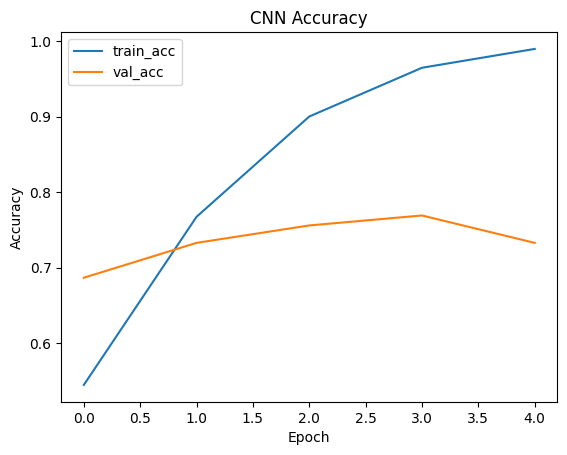

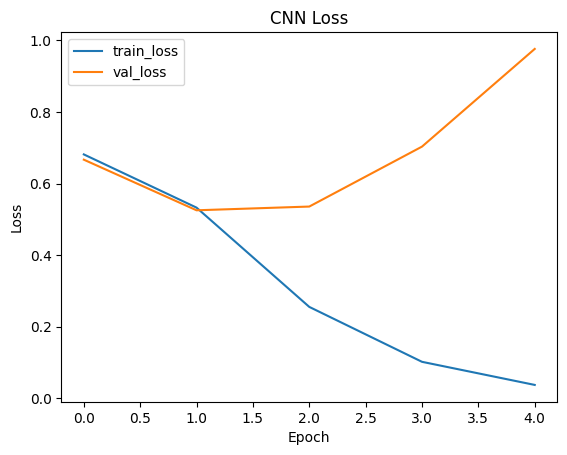

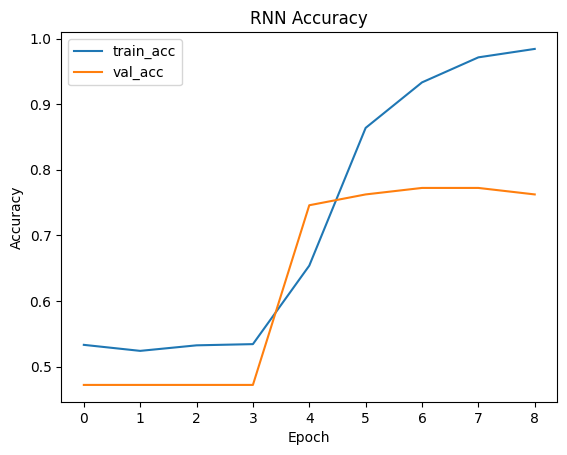

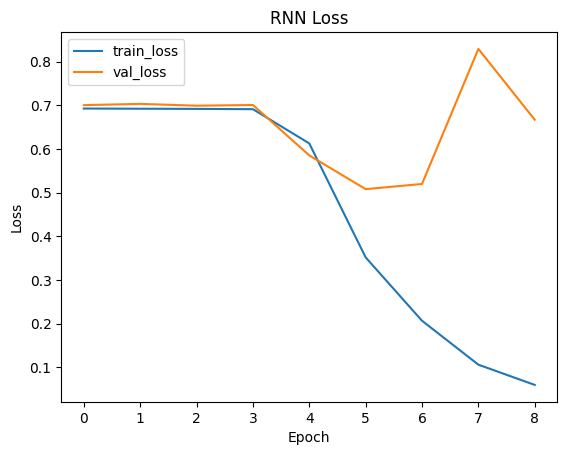

In [ ]:
#CNN Accuracy and Loss
plt.figure()
plt.plot(history_cnn.history['accuracy'],      label='train_acc')
plt.plot(history_cnn.history['val_accuracy'],  label='val_acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
plt.plot(history_cnn.history['loss'],      label='train_loss')
plt.plot(history_cnn.history['val_loss'],  label='val_loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# RNN accuracy & loss
plt.figure()
plt.plot(history_rnn.history['accuracy'],      label='train_acc')
plt.plot(history_rnn.history['val_accuracy'],  label='val_acc')
plt.title('RNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
plt.plot(history_rnn.history['loss'],      label='train_loss')
plt.plot(history_rnn.history['val_loss'],  label='val_loss')
plt.title('RNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# **Pre-training Model (BERT)**

### Packet Installations

In [ ]:
!pip install -U "tensorflow-text==2.15.*"
!pip install -U "tf-models-official==2.15.*"
!pip install tensorflow_hub==0.16.1
!pip install tf-keras
!pip install tf-models-official
!pip install keras-tuner -q
!pip install tensorflow-addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.7 MB/s eta

In [ ]:
# missing dependencies in one go
!pip install --upgrade pip
!pip install tensorflow-addons \
            keras-tuner \
            tensorflow-datasets \
            tf-models-official


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
import os
import shutil
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization
tfhub_handle_preprocess = 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'
tfhub_handle_encoder = 'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/2'
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_models as tfm
import tensorflow_hub as hub
import tensorflow_datasets as tfds
tfds.disable_progress_bar()
import tensorflow_hub as hub
import tensorflow as tf
import kerastuner as kt
import tensorflow as tf
import tensorflow_hub as hub
from official.nlp import optimization
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
import tensorflow_addons as tfa
from tensorflow.keras.optimizers.schedules import PolynomialDecay
import keras_tuner as kt
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
import tensorflow_addons as tfa
from tensorflow.keras.optimizers.schedules import PolynomialDecay
import keras_tuner as kt

<ipython-input-5-7bba6d2bed4d>:18: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt
/usr/local/lib/python3.11/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


### BERT MODEL

In [ ]:
# creating the training and validation dataset
texts = df['Cleaned_Headline'].tolist()
labels = df['Source'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_labels)
val_labels = label_encoder.transform(val_labels)
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Label mapping: {'foxnews': 0, 'nbcnews': 1}


In [ ]:
# Define batch size and autotune setting for efficient data loading
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

# Prepare the training dataset pipeline
# - shuffle: to randomize training samples
# - batch: divide data into batches
# - cache: store data in memory after first load
# - prefetch: overlap data preprocessing and model execution
train_ds = tf.data.Dataset.from_tensor_slices((train_texts, train_labels))
train_ds = train_ds.shuffle(buffer_size=len(train_texts)) \
                   .batch(batch_size) \
                   .cache() \
                   .prefetch(buffer_size=AUTOTUNE)

# Prepare the validation dataset similarly (no need to shuffle)
val_ds = tf.data.Dataset.from_tensor_slices((val_texts, val_labels))
val_ds = val_ds.batch(batch_size) \
               .cache() \
               .prefetch(buffer_size=AUTOTUNE)

# Build the BERT-based classifier model
def build_classifier_model():
    # Define input layer (raw text)
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')

    # Load BERT preprocessing model from TensorFlow Hub
    preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
    encoder_inputs = preprocessing_layer(text_input)

    # Load BERT encoder from TensorFlow Hub (trainable = fine-tune BERT)
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)

    # Use the pooled output [CLS] token representation
    net = outputs['pooled_output']

    # Add dropout for regularization
    net = tf.keras.layers.Dropout(0.1)(net)

    # Final output layer: binary classification with sigmoid activation
    net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)

    # Build the full model
    return tf.keras.Model(text_input, net)

# Define evaluation metrics
metrics = [tf.metrics.BinaryAccuracy()]

# Training configuration
epochs = 5
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1 * num_train_steps)  # 10% of training steps for learning rate warm-up

# Initialize optimizer with learning rate schedule and warm-up
init_lr = 3e-5
optimizer = optimization.create_optimizer(
    init_lr=init_lr,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    optimizer_type='adamw'  # Recommended optimizer for BERT
)

# Build and compile the model
classifier_model = build_classifier_model()
loss = tf.keras.losses.BinaryCrossentropy(from_logits=False)  # Use sigmoid-compatible loss
classifier_model.compile(optimizer=optimizer,
                         loss=loss,
                         metrics=metrics)

# Train the model and store training history
history = classifier_model.fit(train_ds, validation_data=val_ds, epochs=epochs)


Epoch 1/5
95/95 [==============================] - 95s 942ms/step - loss: 0.6317 - binary_accuracy: 0.6340 - val_loss: 0.5165 - val_binary_accuracy: 0.7477
Epoch 2/5
95/95 [==============================] - 89s 932ms/step - loss: 0.5034 - binary_accuracy: 0.7582 - val_loss: 0.4943 - val_binary_accuracy: 0.7609
Epoch 3/5
95/95 [==============================] - 88s 925ms/step - loss: 0.3990 - binary_accuracy: 0.8143 - val_loss: 0.4561 - val_binary_accuracy: 0.7952
Epoch 4/5
95/95 [==============================] - 88s 928ms/step - loss: 0.3411 - binary_accuracy: 0.8487 - val_loss: 0.4731 - val_binary_accuracy: 0.7873
Epoch 5/5
95/95 [==============================] - 89s 933ms/step - loss: 0.3017 - binary_accuracy: 0.8718 - val_loss: 0.4519 - val_binary_accuracy: 0.8018


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()


ax1.plot(history.history['binary_accuracy'],     label='train_acc')
ax1.plot(history.history['val_binary_accuracy'], label='val_acc')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelcolor='tab:blue')


ax2 = ax1.twinx()
ax2.plot(history.history['loss'],     label='train_loss',   linestyle='--')
ax2.plot(history.history['val_loss'], label='val_loss',     linestyle='--')
ax2.set_ylabel('Loss')



lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')


plt.title('BERT Training: Accuracy (left) & Loss (right)')
plt.show()

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


## **Hyper parameter tuning (Bert)**

In [ ]:
batch_size = 32
seq_length = 128
AUTOTUNE   = tf.data.AUTOTUNE

train_ds_hp = tf.data.Dataset.from_tensor_slices((train_texts, train_labels))
val_ds_hp   = tf.data.Dataset.from_tensor_slices((val_texts,   val_labels))

train_ds_hp = train_ds_hp.shuffle(buffer_size=len(train_texts))

train_ds_hp = train_ds_hp.batch(batch_size)
val_ds_hp   = val_ds_hp.batch(batch_size)

preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')

def preprocess_batch(texts, labels):
    tokenized = preprocessing_layer(texts)
    return tokenized, labels

train_ds_hp = train_ds_hp.map(preprocess_batch, num_parallel_calls=AUTOTUNE)
val_ds_hp   = val_ds_hp.map(preprocess_batch,   num_parallel_calls=AUTOTUNE)

train_ds_hp = train_ds_hp.cache().prefetch(buffer_size=AUTOTUNE)
val_ds_hp   = val_ds_hp.cache().prefetch(buffer_size=AUTOTUNE)


In [ ]:
def build_optimizer(learning_rate, weight_decay, num_train_steps, num_warmup_steps):
    decay_schedule = PolynomialDecay(
        initial_learning_rate=learning_rate,
        decay_steps=num_train_steps - num_warmup_steps,
        end_learning_rate=0.0
    )
    class WarmUp(tf.keras.optimizers.schedules.LearningRateSchedule):
        def __init__(self, init_lr, warmup_steps, decay_schedule):
            super().__init__()
            self.init_lr = init_lr
            self.warmup_steps = warmup_steps
            self.decay_schedule = decay_schedule

        def __call__(self, step):
            step = tf.cast(step, tf.float32)
            warmup_steps = tf.cast(self.warmup_steps, tf.float32)
            warmup_lr = self.init_lr * (step / warmup_steps)
            return tf.cond(
                step < warmup_steps,
                lambda: warmup_lr,
                lambda: self.decay_schedule(step - warmup_steps)
            )

    warmup_lr = WarmUp(learning_rate, num_warmup_steps, decay_schedule)

    return tfa.optimizers.AdamW(
        learning_rate=warmup_lr,
        weight_decay=weight_decay
    )

Grid Search

In [ ]:
def build_classifier_model(hp):
    dropout_rate  = hp.Choice('dropout_rate', [0.1, 0.2, 0.3])
    learning_rate = hp.Choice('learning_rate', [2e-5, 3e-5, 5e-5])
    weight_decay  = hp.Choice('weight_decay_rate', [0.0, 0.01, 0.1])
    warmup_prop   = hp.Choice('warmup_proportion', [0.0, 0.1, 0.2])
    epochs        = hp.Int('epochs', 3, 5)

    input_word_ids = tf.keras.Input(shape=(seq_length,), dtype=tf.int32, name='input_word_ids')
    input_mask     = tf.keras.Input(shape=(seq_length,), dtype=tf.int32, name='input_mask')
    input_type_ids = tf.keras.Input(shape=(seq_length,), dtype=tf.int32, name='input_type_ids')
    encoder_inputs = {
        'input_word_ids': input_word_ids,
        'input_mask':     input_mask,
        'input_type_ids': input_type_ids
    }

    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = tf.keras.layers.Dropout(dropout_rate)(outputs['pooled_output'])
    net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)
    model = tf.keras.Model(inputs=encoder_inputs, outputs=net)

    steps_per_epoch  = tf.data.experimental.cardinality(train_ds_hp).numpy()
    num_train_steps  = steps_per_epoch * epochs
    num_warmup_steps = int(warmup_prop * num_train_steps)

    optimizer = build_optimizer(
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        num_train_steps=num_train_steps,
        num_warmup_steps=num_warmup_steps
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )
    return model

tuner_grid = kt.GridSearch(
    build_classifier_model,
    objective='val_binary_accuracy',
    max_trials=8,
    executions_per_trial=1,
    directory='bert_tuning',
    project_name='news_title_cls_Bys'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=1)

tuner_grid.search(
    train_ds_hp,
    validation_data=val_ds_hp,
    epochs=5,
    callbacks=[stop_early]
)

Trial 8 Complete [00h 07m 36s]
val_binary_accuracy: 0.7978863716125488

Best val_binary_accuracy So Far: 0.7992073893547058
Total elapsed time: 00h 56m 46s


In [ ]:
def build_classifier_larger_model(hp):
    # Hyperparameter
    dropout_rate  = hp.Choice('dropout_rate', [0.1, 0.2, 0.3, 0.4, 0.5])
    learning_rate = hp.Choice('learning_rate', [1e-5, 2e-5, 3e-5, 5e-5, 8e-5, 1e-4])
    weight_decay  = hp.Choice('weight_decay_rate', [0.0, 0.01, 0.05, 0.1, 0.2])
    warmup_prop   = hp.Choice('warmup_proportion', [0.0, 0.05, 0.1, 0.15, 0.2, 0.3])
    epochs        = hp.Int('epochs', min_value=3, max_value=10, step=1)

    # input model
    input_word_ids = tf.keras.Input(shape=(seq_length,), dtype=tf.int32, name='input_word_ids')
    input_mask     = tf.keras.Input(shape=(seq_length,), dtype=tf.int32, name='input_mask')
    input_type_ids = tf.keras.Input(shape=(seq_length,), dtype=tf.int32, name='input_type_ids')
    encoder_inputs = {
        'input_word_ids': input_word_ids,
        'input_mask':     input_mask,
        'input_type_ids': input_type_ids
    }

    # BERT Encoder
    encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
    outputs = encoder(encoder_inputs)
    net = tf.keras.layers.Dropout(dropout_rate)(outputs['pooled_output'])
    net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)
    model = tf.keras.Model(inputs=encoder_inputs, outputs=net)

    # steps
    steps_per_epoch  = tf.data.experimental.cardinality(train_ds_hp).numpy()
    num_train_steps  = steps_per_epoch * epochs
    num_warmup_steps = int(warmup_prop * num_train_steps)

    optimizer = build_optimizer(
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        num_train_steps=num_train_steps,
        num_warmup_steps=num_warmup_steps
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
        metrics=[tf.keras.metrics.BinaryAccuracy()]
    )
    return model

Random Search

Reloading Tuner from bert_tuning/news_title_cls/tuner0.json
Epoch 1/4
95/95 [==============================] - 94s 929ms/step - loss: 0.6155 - binary_accuracy: 0.6568 - val_loss: 0.4918 - val_binary_accuracy: 0.7517
Epoch 2/4
95/95 [==============================] - 88s 926ms/step - loss: 0.4517 - binary_accuracy: 0.7859 - val_loss: 0.4691 - val_binary_accuracy: 0.7847
Epoch 3/4
95/95 [==============================] - 90s 949ms/step - loss: 0.3373 - binary_accuracy: 0.8520 - val_loss: 0.4385 - val_binary_accuracy: 0.8058
Epoch 4/4
95/95 [==============================] - 88s 931ms/step - loss: 0.2588 - binary_accuracy: 0.8913 - val_loss: 0.4410 - val_binary_accuracy: 0.8098
Epoch 1/4
95/95 [==============================] - 94s 939ms/step - loss: 0.6340 - binary_accuracy: 0.6283 - val_loss: 0.5392 - val_binary_accuracy: 0.7292
Epoch 2/4
95/95 [==============================] - 89s 936ms/step - loss: 0.5180 - binary_accuracy: 0.7463 - val_loss: 0.4836 - val_binary_accuracy: 0.7728
Epoc

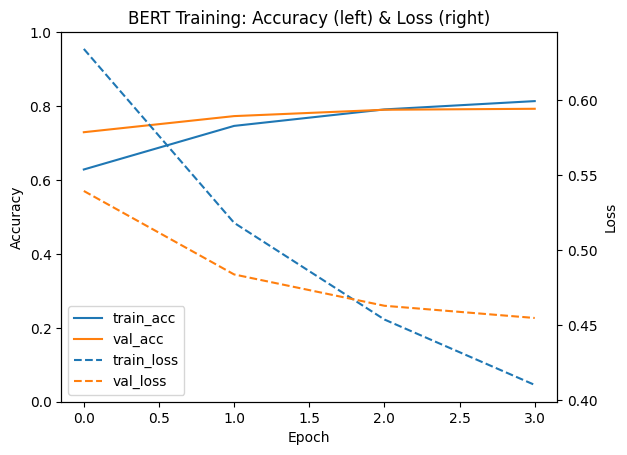

In [ ]:
# Smaller Model
tuner_random_small = kt.RandomSearch(
    build_classifier_model,
    objective='val_binary_accuracy',
    max_trials=8,
    executions_per_trial=1,
    directory='bert_tuning',
    project_name='news_title_cls'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=1)

tuner_random_small.search(
    train_ds_hp,
    validation_data=val_ds_hp,
    epochs=5,
    callbacks=[stop_early])

best_hp = tuner_random_small.get_best_hyperparameters(num_trials=1)[0]
bert_model_hp = tuner_random_small.hypermodel.build(best_hp)
history_bert = bert_model_hp.fit(
    train_ds_hp,
    validation_data=val_ds_hp,
    epochs=best_hp.get('epochs')
)

%matplotlib inline
import matplotlib.pyplot as plt

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
bert_model_hp = tuner.hypermodel.build(best_hp)
history_bert = bert_model_hp.fit(
    train_ds_hp,
    validation_data=val_ds_hp,
    epochs=best_hp.get('epochs')
)

fig, ax1 = plt.subplots()

# Accuracy on left y-axis
ax1.plot(history_bert.history['binary_accuracy'],     label='train_acc')
ax1.plot(history_bert.history['val_binary_accuracy'], label='val_acc')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)

# Loss on right y-axis
ax2 = ax1.twinx()
ax2.plot(history_bert.history['loss'],     label='train_loss', linestyle='--')
ax2.plot(history_bert.history['val_loss'], label='val_loss',   linestyle='--')
ax2.set_ylabel('Loss')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title('BERT Training: Accuracy (left) & Loss (right)')
plt.show()


In [ ]:
# Larger Model
tuner_random_large = kt.RandomSearch(
    build_classifier_larger_model,
    objective='val_binary_accuracy',
    max_trials=8,
    executions_per_trial=1,
    directory='bert_tuning',
    project_name='news_title_cls'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=1)

tuner_random_large.search(
    train_ds_hp,
    validation_data=val_ds_hp,
    epochs=5,
    callbacks=[stop_early])

best_hp = tuner_random_large.get_best_hyperparameters(num_trials=1)[0]
bert_model_hp = tuner_random_large.hypermodel.build(best_hp)
history_bert = bert_model_hp.fit(
    train_ds_hp,
    validation_data=val_ds_hp,
    epochs=best_hp.get('epochs')
)

Reloading Tuner from bert_tuning/news_title_cls/tuner0.json
Epoch 1/4
95/95 [==============================] - 93s 925ms/step - loss: 0.6102 - binary_accuracy: 0.6749 - val_loss: 0.5065 - val_binary_accuracy: 0.7477
Epoch 2/4
95/95 [==============================] - 88s 927ms/step - loss: 0.4564 - binary_accuracy: 0.7810 - val_loss: 0.5226 - val_binary_accuracy: 0.7728
Epoch 3/4
95/95 [==============================] - 87s 921ms/step - loss: 0.3452 - binary_accuracy: 0.8494 - val_loss: 0.4287 - val_binary_accuracy: 0.8058
Epoch 4/4
95/95 [==============================] - 88s 926ms/step - loss: 0.2742 - binary_accuracy: 0.8804 - val_loss: 0.4267 - val_binary_accuracy: 0.8005


# **Ensemble**


In [ ]:

# Ensemble Model with Engineered Features

import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from scipy.sparse import hstack, csr_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings

# ignoring warning clutter
warnings.filterwarnings("ignore")


df = pd.read_csv("preprocessed_headlines.csv")

# helper to pull domain out of a URL
def extract_domain(url):
    try:
        return urlparse(url).netloc
    except Exception:
        return "unknown"

# adding 'Source' column if missing
if 'Source' not in df.columns:
    df['Source'] = df['URL'].apply(extract_domain)

# using cleaned headlines as text feature
X_text = df['Cleaned_Headline'].astype(str)
y_labels = df['Source']

# encoding string labels into integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_

# splitting into train/test
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

#additional text based numeric features
class ExtendedTextFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        features = []
        for text in X:
            words = text.split()
            word_count = len(words)
            char_count = len(text)
            avg_word_length = np.mean([len(w) for w in words]) if words else 0
            digit_count = len(re.findall(r'\d', text))
            punctuation_count = len(re.findall(r'[!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]', text))
            uppercase_count = sum(1 for w in words if w.isupper())
            features.append([
                word_count,
                char_count,
                avg_word_length,
                digit_count,
                punctuation_count,
                uppercase_count
            ])
        return np.array(features)

# Building TF IDF unions for word and char n grams
tfidf_union = FeatureUnion([
    ('word_ngrams', TfidfVectorizer(
         ngram_range=(1,2),
         max_features=5000,
         max_df=0.95,
         min_df=2,
         norm='l2'
    )),
    ('char_ngrams', TfidfVectorizer(
         analyzer='char_wb',
         ngram_range=(3,5),
         max_features=3000,
         max_df=0.95,
         min_df=1,
         norm='l2'
    ))
])

# numeric pipeline to scale extended features
numeric_pipeline = Pipeline([
    ('ext_feats', ExtendedTextFeatures()),
    ('scaler', StandardScaler())
])

# combining TF IDF and numeric pipelines
class CombinedFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, tfidf_transformer, numeric_transformer):
        self.tfidf_transformer = tfidf_transformer
        self.numeric_transformer = numeric_transformer

    def fit(self, X, y=None):
        self.tfidf_transformer.fit(X, y)
        self.numeric_transformer.fit(X, y)
        return self

    def transform(self, X, y=None):
        X_tfidf = self.tfidf_transformer.transform(X)
        X_numeric = self.numeric_transformer.transform(X)
        X_numeric_sparse = csr_matrix(X_numeric)
        return hstack([X_tfidf, X_numeric_sparse])

combined_features = CombinedFeatures(tfidf_union, numeric_pipeline)

# building and training voting ensemble
# logistic regression with balanced classes
clf_lr = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42,
    C=10
)
# random forest with deep, balanced forest
clf_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    class_weight='balanced',
    random_state=42
)
# soft voting to average probabilities
voting_ensemble = VotingClassifier(
    estimators=[('lr', clf_lr), ('rf', clf_rf)],
    voting='soft',
    n_jobs=-1
)

# full pipeline combining features + classifier
final_pipeline = Pipeline([
    ('combined_feats', combined_features),
    ('clf', voting_ensemble)
])

print("Training final pipeline with extended engineered features...")
final_pipeline.fit(X_train_text, y_train)

#Evaluating on hold out test set
y_pred = final_pipeline.predict(X_test_text)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%\n")
print("Classification Report:\n",
      classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


Training final pipeline with extended engineered features...
Test Accuracy: 80.71%

Classification Report:
                  precision    recall  f1-score   support

    foxnews.com       0.00      0.00      0.00         2
www.foxnews.com       0.80      0.84      0.82       398
www.nbcnews.com       0.81      0.78      0.79       357

       accuracy                           0.81       757
      macro avg       0.54      0.54      0.54       757
   weighted avg       0.81      0.81      0.81       757



#**Test Data Report**

In [ ]:
#NEW TEST DATA PREDICTIONS
import pandas as pd

#Loading preprocessed test file
df_test = pd.read_csv("preprocessed_new_data.csv")

# Verifying columns
print("Test set columns:", df_test.columns.tolist())

#Predicting with tuned LR
submission_preds = final_model.predict(df_test["Cleaned_Headline"])

#building and saving one column CSV
submission = pd.DataFrame(submission_preds, columns=["Label"])
submission.to_csv("submission_new_test.csv", index=False)

print(f" submission_new_test.csv written with {len(submission)} rows (no index).")

